# HDAC8 QSAR models (ECFP4)

Regression models for HDAC8 pChEMBL on the scaffold-split sets `HDAC8_train.sdf` and `HDAC8_test.sdf`.

Descriptors: Morgan/ECFP4 fingerprints (`radius=2`). Hyperparameters are tuned with **Optuna** (TPE + median pruning) instead of `GridSearchCV`.

**What changed vs the previous notebook**
- Reads the curated revision files (not `datasets/HDAC8_work.sdf`).
- Fingerprints via `rdFingerprintGenerator` (the old `GetMorganFingerprintAsBitVect` API is deprecated).
- Shared evaluation: train R², 5-fold Q², external R², AD-filtered external R². Test-set R² is no longer labeled Q².
- SVM/MLP use `Pipeline` + `StandardScaler` (no preprocessing leakage in CV).
- kNN no longer assigns training fingerprints to `x_ts`.
- Applicability domain is computed once with Tanimoto distance $D_{\text{Tanimoto}} = 1 - T_c$ (k = 1). Membership means similarity to the training fingerprint space, not that an individual prediction is reliable.
- Model save/load paths are consistent under `models/ECFP4/`.


## 1. Imports and settings


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import optuna
from IPython.display import display
import ipywidgets as widgets
from catboost import CatBoostRegressor
from molvs import standardize_smiles
from rdkit import Chem, RDLogger
from rdkit.Chem import rdFingerprintGenerator
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict, permutation_test_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

RDLogger.DisableLog("rdApp.*")
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
ACTIVITY_PROP = "pchembl_value_mean"
TRAIN_SDF = Path("HDAC8_train.sdf")
TEST_SDF = Path("HDAC8_test.sdf")
MODEL_DIR = Path("models/ECFP4")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

FP_RADIUS = 2
FP_SIZE = 2048
AD_Z = 0.5

# Set True for a short debug run.
QUICK_RUN = False
N_SPLITS_SEARCH = 3 if QUICK_RUN else 5
N_TRIALS = {
    "CatBoost": 8 if QUICK_RUN else 40,
    "SVR": 8 if QUICK_RUN else 35,
    "MLP": 6 if QUICK_RUN else 25,
    "kNN": 8 if QUICK_RUN else 25,
}
N_PERMUTATIONS = 5 if QUICK_RUN else 20

cv_search = KFold(n_splits=N_SPLITS_SEARCH, shuffle=True, random_state=SEED)
cv_final = KFold(n_splits=5, shuffle=True, random_state=SEED)
rng = np.random.RandomState(SEED)


## 2. Data loading and curation

Molecules are sanitized and standardized with MolVS. Failed structures are dropped together with their activity values. The endpoint is `pchembl_value_mean` from the revision SDF files.


In [2]:
def load_sdf(path, activity_prop=ACTIVITY_PROP):
    supplier = Chem.ForwardSDMolSupplier(str(path), sanitize=False)
    rows, failed = [], []

    for i, mol in enumerate(supplier):
        rec = {"index": i + 1}
        if mol is None:
            failed.append({**rec, "reason": "unreadable record"})
            continue

        rec["chembl_id"] = mol.GetProp("molecule_chembl_id") if mol.HasProp("molecule_chembl_id") else f"mol_{i+1}"
        rec["smiles_raw"] = (
            mol.GetProp("canonical_smiles") if mol.HasProp("canonical_smiles") else Chem.MolToSmiles(mol)
        )
        rec["scaffold"] = mol.GetProp("scaffold") if mol.HasProp("scaffold") else ""
        try:
            rec["y"] = float(mol.GetProp(activity_prop))
        except Exception as exc:
            failed.append({**rec, "reason": f"missing/invalid {activity_prop}: {exc}"})
            continue

        try:
            Chem.SanitizeMol(mol)
            std_smi = standardize_smiles(Chem.MolToSmiles(mol))
            std_mol = Chem.MolFromSmiles(std_smi)
            if std_mol is None:
                raise ValueError("MolFromSmiles returned None after standardization")
        except Exception as exc:
            failed.append({**rec, "reason": str(exc)})
            continue

        rec.update({"mol": std_mol, "smiles": std_smi})
        rows.append(rec)

    data = pd.DataFrame(rows)
    failed = pd.DataFrame(failed)
    print(f"{path.name}: kept {len(data)} / {len(data) + len(failed)} molecules ({len(failed)} failed)")
    return data, failed


train_df, train_failed = load_sdf(TRAIN_SDF)
test_df, test_failed = load_sdf(TEST_SDF)

display(train_failed if len(train_failed) else "No failed training molecules")
display(test_failed if len(test_failed) else "No failed test molecules")


HDAC8_train.sdf: kept 2093 / 2093 molecules (0 failed)
HDAC8_test.sdf: kept 523 / 523 molecules (0 failed)


'No failed training molecules'

'No failed test molecules'

Train: n = 2093, pChEMBL = 6.020 ± 0.869 [4.01, 9.99], scaffolds = 1106
Test: n = 523, pChEMBL = 6.168 ± 0.938 [4.03, 9.43], scaffolds = 224
Shared Murcko scaffolds: 0


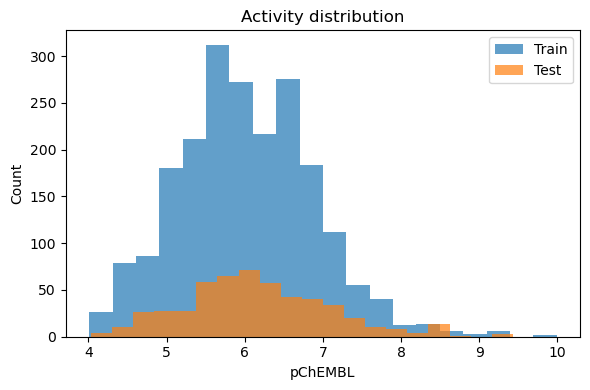

,index,chembl_id,smiles_raw,scaffold,y,mol,smiles
0,1,CHEMBL4299447,CC[C@@H]1OC(=O)[C@@H](C)[C@H](O[C@H]2C[C@@](C)...,O=C1C[C@H](O[C@H]2CCCCO2)C[C@H](O[C@@H]2CCCCO2...,5.77,<rdkit.Chem.rdchem.Mol object at 0x000001EBF7F...,CC[C@@H]1OC(=O)[C@@H](C)[C@H](O[C@H]2C[C@@](C)...
1,2,CHEMBL5899207,CC(C)c1ccc(-c2cc3ccc(C(=O)NO)cc3s2)cc1,c1ccc(-c2cc3ccccc3s2)cc1,5.96,<rdkit.Chem.rdchem.Mol object at 0x000001EBF7F...,CC(C)c1ccc(-c2cc3ccc(C(=O)NO)cc3s2)cc1
2,3,CHEMBL4454484,O=C(CCCCCCCNC(=O)c1c(-c2ccc(O)cc2)sc2cc(O)ccc1...,c1ccc(-c2cc3ccccc3s2)cc1,6.40,<rdkit.Chem.rdchem.Mol object at 0x000001EBF7F...,O=C(CCCCCCCNC(=O)c1c(-c2ccc(O)cc2)sc2cc(O)ccc1...
3,4,CHEMBL4533192,O=C(CCCCCCNC(=O)c1c(-c2ccc(O)cc2)sc2cc(O)ccc12)NO,c1ccc(-c2cc3ccccc3s2)cc1,6.27,<rdkit.Chem.rdchem.Mol object at 0x000001EBF7F...,O=C(CCCCCCNC(=O)c1c(-c2ccc(O)cc2)sc2cc(O)ccc12)NO
4,5,CHEMBL4283105,O=C(NO)c1ccc(Cn2c3c(c4cc(F)ccc42)C[S+]([O-])CC...,c1ccc(Cn2c3c(c4ccccc42)C[SH+]CC3)cc1,5.62,<rdkit.Chem.rdchem.Mol object at 0x000001EBF7F...,O=C(NO)c1ccc(Cn2c3c(c4cc(F)ccc42)C[S+]([O-])CC...


In [3]:
def summarize_split(name, df):
    print(
        f"{name}: n = {len(df)}, "
        f"pChEMBL = {df['y'].mean():.3f} ± {df['y'].std():.3f} "
        f"[{df['y'].min():.2f}, {df['y'].max():.2f}], "
        f"scaffolds = {df['scaffold'].nunique()}"
    )


summarize_split("Train", train_df)
summarize_split("Test", test_df)

shared = set(train_df["scaffold"]) & set(test_df["scaffold"])
shared.discard("")
print("Shared Murcko scaffolds:", len(shared))
if shared:
    raise AssertionError("Scaffold leakage between train and test.")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(train_df["y"], bins=20, alpha=0.7, label="Train")
ax.hist(test_df["y"], bins=20, alpha=0.7, label="Test")
ax.set_xlabel("pChEMBL")
ax.set_ylabel("Count")
ax.set_title("Activity distribution")
ax.legend()
plt.tight_layout()
plt.show()

train_df.head()


## 3. ECFP4 fingerprints

Morgan fingerprints, radius 2 (ECFP4), 2048 bits. `fpSize=2048` reduces bit collisions relative to the previous 1024-bit setup. The same generator is used for train and test.


In [4]:
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=FP_RADIUS, fpSize=FP_SIZE)


def fingerprints(mols):
    return np.vstack([np.asarray(mfpgen.GetFingerprint(mol), dtype=np.float32) for mol in mols])


X_tr = fingerprints(train_df["mol"])
X_ts = fingerprints(test_df["mol"])
y_tr = train_df["y"].to_numpy(dtype=np.float64)
y_ts = test_df["y"].to_numpy(dtype=np.float64)

print("X_train:", X_tr.shape, "X_test:", X_ts.shape)
print("Mean on-bits / molecule: train {:.1f}, test {:.1f}".format(X_tr.sum(1).mean(), X_ts.sum(1).mean()))

np.savetxt(MODEL_DIR / "x_tr_ECFP4.csv", X_tr, delimiter=",")
np.savetxt(MODEL_DIR / "x_ts_ECFP4.csv", X_ts, delimiter=",")
np.savetxt(MODEL_DIR / "y_tr.csv", y_tr, delimiter=",")
np.savetxt(MODEL_DIR / "y_ts.csv", y_ts, delimiter=",")


X_train: (2093, 2048) X_test: (523, 2048)
Mean on-bits / molecule: train 51.4, test 48.0


## 4. Shared utilities

OECD-style metrics: R² on the training set, Q² from cross-validation, and external R² on the held-out scaffold test set.

**Applicability domain (AD).** ECFP4 bits are binary and sparse. Euclidean distance treats shared *off*-bits as similarity and is not the usual comparison for Morgan fingerprints. The chemically appropriate metric is the Tanimoto (Jaccard) coefficient on on-bits, reported as a distance:

$$D_{\mathrm{Tanimoto}}(a,b) = 1 - T_c(a,b) = 1 - \frac{|A \cap B|}{|A \cup B|}$$

The AD threshold is $\bar{d} + 0.5\,\sigma$ of the nearest-neighbour $D_{\mathrm{Tanimoto}}$ values in the training set (k = 1). A query is inside the domain if its nearest training neighbour satisfies $D_{\mathrm{Tanimoto}} \le d_{\mathrm{limit}}$.

In-AD membership only means the compound is similar to the training fingerprint space. It is **not** proof that an individual prediction is reliable: in-AD compounds can still be mispredicted, and AD-filtered statistics describe the interpolative subset only.

Test-set predictions are appended to `models/ECFP4/test_predictions.csv` immediately after each model is evaluated.


In [5]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def ccc(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mean_t, mean_p = y_true.mean(), y_pred.mean()
    var_t, var_p = y_true.var(), y_pred.var()
    cov = np.mean((y_true - mean_t) * (y_pred - mean_p))
    denom = var_t + var_p + (mean_t - mean_p) ** 2
    return float(2 * cov / denom) if denom else np.nan


def regression_metrics(y_true, y_pred):
    return {
        "R2": float(r2_score(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "CCC": ccc(y_true, y_pred),
    }


def tanimoto_distance(X, Y=None):
    """Pairwise D_Tanimoto = 1 - T_c for binary fingerprints.

    T_c(a, b) = |A ∩ B| / |A ∪ B|. Two all-zero vectors are treated as identical (T_c = 1).
    For binary vectors this is the Jaccard distance.
    """
    X = np.asarray(X, dtype=np.float64)
    Y = X if Y is None else np.asarray(Y, dtype=np.float64)
    intersection = X @ Y.T
    x_pop = X.sum(axis=1, keepdims=True)
    y_pop = Y.sum(axis=1, keepdims=True)
    union = x_pop + y_pop.T - intersection
    tc = np.divide(intersection, union, out=np.ones_like(intersection), where=union > 0)
    return 1.0 - tc


def compute_ad(X_train, z=AD_Z):
    dist = tanimoto_distance(X_train)
    np.fill_diagonal(dist, np.inf)
    nn = dist.min(axis=1)
    limit = float(nn.mean() + z * nn.std(ddof=0))
    return limit, nn


def apply_ad(X_train, X_test, limit):
    dist = tanimoto_distance(X_test, X_train)
    nn = dist.min(axis=1)
    return nn <= limit, nn


def plot_obs_pred(y_true, y_pred, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(4.2, 4.2))
    lo = min(y_true.min(), y_pred.min()) - 0.2
    hi = max(y_true.max(), y_pred.max()) + 0.2
    ax.scatter(y_true, y_pred, s=16, alpha=0.65, edgecolors="none")
    ax.plot([lo, hi], [lo, hi], color="black", lw=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel("Observed pChEMBL")
    ax.set_ylabel("Predicted pChEMBL")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    return ax


def cv_r2_pruned(trial, factory, X, y, cv, fit_params=None):
    fit_params = fit_params or {}
    scores = []
    for step, (tr_idx, va_idx) in enumerate(cv.split(X, y)):
        model = factory()
        model.fit(X[tr_idx], y[tr_idx], **fit_params)
        pred = model.predict(X[va_idx])
        scores.append(r2_score(y[va_idx], pred))
        trial.report(float(np.mean(scores)), step)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(scores))


def run_study(name, objective, n_trials):
    sampler = optuna.samplers.TPESampler(seed=SEED)
    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1)
    study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner, study_name=name)

    # Optuna's tqdm.notebook bar often fails in Jupyter Notebook 7
    # ("Error displaying widget: model not found"). Use core ipywidgets instead.
    bar = widgets.IntProgress(value=0, min=0, max=n_trials, description=name, bar_style="info")
    label = widgets.HTML(value="starting&hellip;")
    display(widgets.HBox([bar, label]))

    def on_trial(study, trial):
        bar.value = len(study.trials)
        if trial.state.name == "PRUNED":
            label.value = f"trial {trial.number} pruned; best CV R² = {study.best_value:.4f}"
        elif trial.value is not None:
            label.value = (
                f"trial {trial.number}: CV R² = {trial.value:.4f}; "
                f"best = {study.best_value:.4f} (trial {study.best_trial.number})"
            )
        if bar.value >= n_trials:
            bar.bar_style = "success"

    study.optimize(objective, n_trials=n_trials, show_progress_bar=False, callbacks=[on_trial])
    print(f"{name}: best CV R2 = {study.best_value:.4f}")
    print("Best params:", study.best_params)
    return study


def evaluate_model(name, estimator, X_tr, y_tr, X_ts, y_ts, in_ad, fit_params=None, cv_fit_params=None):
    fit_params = fit_params or {}
    cv_fit_params = cv_fit_params or {}
    model = clone(estimator)
    model.fit(X_tr, y_tr, **fit_params)

    y_hat_tr = model.predict(X_tr)
    y_hat_cv = cross_val_predict(clone(estimator), X_tr, y_tr, cv=cv_final, n_jobs=1, params=cv_fit_params)
    y_hat_ts = model.predict(X_ts)

    train_m = regression_metrics(y_tr, y_hat_tr)
    cv_m = regression_metrics(y_tr, y_hat_cv)
    test_m = regression_metrics(y_ts, y_hat_ts)

    coverage = float(in_ad.mean()) if len(in_ad) else np.nan
    if in_ad.any():
        ad_m = regression_metrics(y_ts[in_ad], y_hat_ts[in_ad])
    else:
        ad_m = {k: np.nan for k in test_m}

    row = {
        "model": name,
        "R2_train": train_m["R2"],
        "RMSE_train": train_m["RMSE"],
        "Q2_CV": cv_m["R2"],
        "RMSE_CV": cv_m["RMSE"],
        "MAE_CV": cv_m["MAE"],
        "R2_ext": test_m["R2"],
        "RMSE_ext": test_m["RMSE"],
        "MAE_ext": test_m["MAE"],
        "CCC_ext": test_m["CCC"],
        "R2_ext_AD": ad_m["R2"],
        "RMSE_ext_AD": ad_m["RMSE"],
        "AD_coverage": coverage,
    }

    print(pd.Series(row).to_string())
    fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.0))
    plot_obs_pred(y_tr, y_hat_tr, f"{name} train  R2={train_m['R2']:.3f}", ax=axes[0])
    plot_obs_pred(y_tr, y_hat_cv, f"{name} 5-fold CV  Q2={cv_m['R2']:.3f}", ax=axes[1])
    plot_obs_pred(y_ts, y_hat_ts, f"{name} test  R2={test_m['R2']:.3f}", ax=axes[2])
    if (~in_ad).any():
        axes[2].scatter(
            y_ts[~in_ad],
            y_hat_ts[~in_ad],
            s=28,
            facecolors="none",
            edgecolors="crimson",
            label="outside training space (AD)",
        )
        axes[2].legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()
    write_test_predictions(name, y_hat_ts)
    return model, row, {"train": y_hat_tr, "cv": y_hat_cv, "test": y_hat_ts}


def write_test_predictions(name, y_hat_ts):
    pred_table[f"pred_{name}"] = np.asarray(y_hat_ts)
    pred_table.to_csv(MODEL_DIR / "test_predictions.csv", index=False)
    print(f"Updated {MODEL_DIR / 'test_predictions.csv'} with pred_{name}")
    cols = ["chembl_id", "pchembl_obs", f"pred_{name}", "in_AD", "D_Tanimoto", "T_c"]
    display(pred_table[cols].head())


results = []
fitted = {}
preds = {}
studies = {}


Train NN D_Tanimoto: 0.249 ± 0.154
AD limit (mean + 0.5*SD): 0.326
Test compounds similar to training space: 0.482 (252/523)
in-AD = nearest-neighbour Tanimoto similarity to the training set, not a reliability certificate.


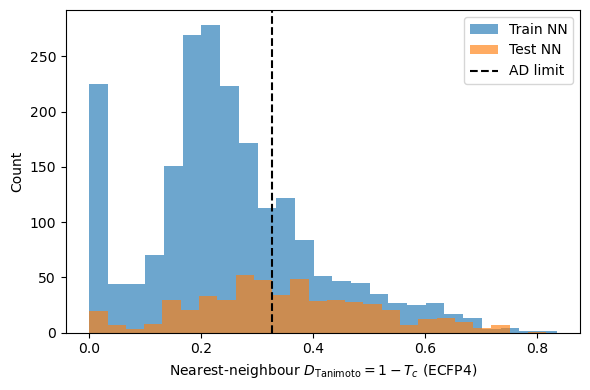

In [6]:
ad_limit, nn_train = compute_ad(X_tr)
in_ad, nn_test = apply_ad(X_tr, X_ts, ad_limit)

pred_table = test_df[["chembl_id", "smiles", "scaffold", "y"]].rename(columns={"y": "pchembl_obs"}).copy()
pred_table["in_AD"] = in_ad
pred_table["D_Tanimoto"] = nn_test
pred_table["T_c"] = 1.0 - nn_test
pred_table.to_csv(MODEL_DIR / "test_predictions.csv", index=False)

print(f"Train NN D_Tanimoto: {nn_train.mean():.3f} ± {nn_train.std():.3f}")
print(f"AD limit (mean + {AD_Z}*SD): {ad_limit:.3f}")
print(f"Test compounds similar to training space: {in_ad.mean():.3f} ({in_ad.sum()}/{len(in_ad)})")
print("in-AD = nearest-neighbour Tanimoto similarity to the training set, not a reliability certificate.")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(nn_train, bins=25, alpha=0.65, label="Train NN")
ax.hist(nn_test, bins=25, alpha=0.65, label="Test NN")
ax.axvline(ad_limit, color="black", ls="--", label="AD limit")
ax.set_xlabel(r"Nearest-neighbour $D_{\mathrm{Tanimoto}} = 1 - T_c$ (ECFP4)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()


## 5. CatBoost

Trees do not need scaling. Search space covers depth, learning rate, L2, leaf size and boosting rounds. Each trial is scored by mean 5-fold R² with median pruning.


CatBoost: best CV R2 = 0.5666
Best params: {'depth': 10, 'learning_rate': 0.04090868695059145, 'l2_leaf_reg': 1.362220927415009, 'min_data_in_leaf': 5, 'iterations': 900}
model          CatBoost
R2_train       0.927284
RMSE_train     0.234333
Q2_CV          0.567192
RMSE_CV          0.5717
MAE_CV         0.411084
R2_ext         0.395265
RMSE_ext       0.728479
MAE_ext         0.55322
CCC_ext        0.545617
R2_ext_AD      0.479812
RMSE_ext_AD    0.663975
AD_coverage    0.481836


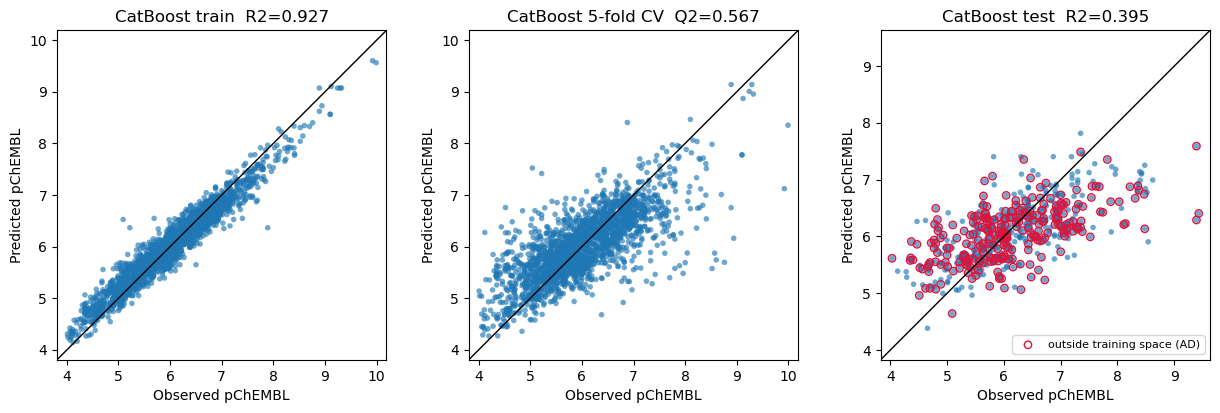

Updated models\ECFP4\test_predictions.csv with pred_CatBoost


,chembl_id,pchembl_obs,pred_CatBoost,in_AD,D_Tanimoto,T_c
0,CHEMBL5184762,5.89,6.070976,True,0.320755,0.679245
1,CHEMBL4218901,4.47,6.264312,True,0.300000,0.700000
2,CHEMBL4464527,6.24,6.567318,True,0.269231,0.730769
3,CHEMBL4213975,4.62,6.281340,True,0.270833,0.729167
4,CHEMBL4206647,5.46,6.247430,False,0.392157,0.607843


['models\\ECFP4\\CatBoost_ECFP4.pkl']

In [7]:
def objective_catboost(trial):
    params = {
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 12.0, log=True),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 20),
        "iterations": trial.suggest_int("iterations", 200, 1000, step=100),
        "random_seed": SEED,
        "verbose": False,
        "loss_function": "RMSE",
        "allow_writing_files": False,
    }
    return cv_r2_pruned(trial, lambda: CatBoostRegressor(**params), X_tr, y_tr, cv_search)


studies["CatBoost"] = run_study("CatBoost", objective_catboost, N_TRIALS["CatBoost"])
best_cat = CatBoostRegressor(
    **studies["CatBoost"].best_params,
    random_seed=SEED,
    verbose=False,
    loss_function="RMSE",
    allow_writing_files=False,
)
cat_fit = {"verbose": False}
fitted["CatBoost"], row, preds["CatBoost"] = evaluate_model(
    "CatBoost", best_cat, X_tr, y_tr, X_ts, y_ts, in_ad, fit_params=cat_fit, cv_fit_params=cat_fit
)
results.append(row)
joblib.dump(fitted["CatBoost"], MODEL_DIR / "CatBoost_ECFP4.pkl")


## 6. Support vector regression

RBF-SVR inside a `Pipeline` with `StandardScaler`, so scaling is fit only on each CV training fold. `C`, `gamma` and `epsilon` are searched on a log/linear scale covering the old grid and intermediate values.


SVR: best CV R2 = 0.5062
Best params: {'C': 498.2304078245292, 'gamma': 0.0003880951655302834, 'epsilon': 0.2152178229754078}
model               SVR
R2_train       0.944225
RMSE_train      0.20523
Q2_CV          0.506185
RMSE_CV        0.610664
MAE_CV          0.45178
R2_ext         0.353359
RMSE_ext       0.753297
MAE_ext        0.580484
CCC_ext        0.519149
R2_ext_AD      0.462338
RMSE_ext_AD    0.675034
AD_coverage    0.481836


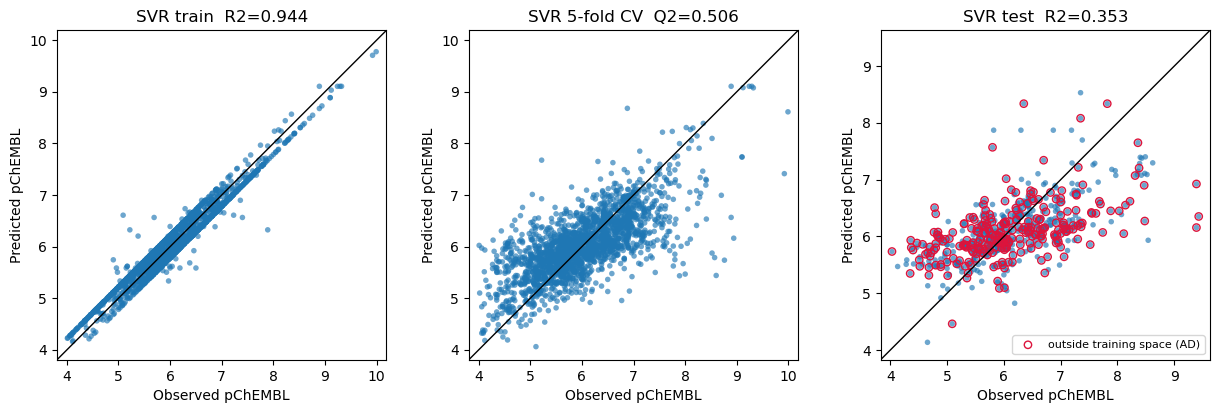

Updated models\ECFP4\test_predictions.csv with pred_SVR


,chembl_id,pchembl_obs,pred_SVR,in_AD,D_Tanimoto,T_c
0,CHEMBL5184762,5.89,5.755923,True,0.320755,0.679245
1,CHEMBL4218901,4.47,5.810063,True,0.300000,0.700000
2,CHEMBL4464527,6.24,6.584400,True,0.269231,0.730769
3,CHEMBL4213975,4.62,5.835640,True,0.270833,0.729167
4,CHEMBL4206647,5.46,5.720523,False,0.392157,0.607843


['models\\ECFP4\\SVM_ECFP4.pkl']

In [8]:
def make_svr(C, gamma, epsilon):
    return Pipeline(
        [
            ("scaler", StandardScaler()),
            ("svr", SVR(kernel="rbf", C=C, gamma=gamma, epsilon=epsilon, cache_size=500)),
        ]
    )


def objective_svr(trial):
    C = trial.suggest_float("C", 0.1, 1e4, log=True)
    gamma = trial.suggest_float("gamma", 1e-6, 1e-1, log=True)
    epsilon = trial.suggest_float("epsilon", 0.01, 0.5)
    return cv_r2_pruned(trial, lambda: make_svr(C, gamma, epsilon), X_tr, y_tr, cv_search)


studies["SVR"] = run_study("SVR", objective_svr, N_TRIALS["SVR"])
best_svr = make_svr(**studies["SVR"].best_params)
fitted["SVR"], row, preds["SVR"] = evaluate_model("SVR", best_svr, X_tr, y_tr, X_ts, y_ts, in_ad)
results.append(row)
joblib.dump(fitted["SVR"], MODEL_DIR / "SVM_ECFP4.pkl")


## 7. Multi-layer perceptron

The previous grid mixed oversized networks (`(400, 300, 200, 100)`) with `lbfgs`/`sgd` and was too expensive for ~2k × 2048 inputs. Search is limited to 1–3 hidden layers, Adam, L2 and learning rate, with early stopping.


MLP: best CV R2 = 0.0342
Best params: {'n_layers': 3, 'n_units': 192, 'activation': 'relu', 'alpha': 0.001221138638830409, 'learning_rate_init': 0.00168102240000606}
model               MLP
R2_train       0.858406
RMSE_train     0.326996
Q2_CV          0.036469
RMSE_CV        0.853008
MAE_CV         0.632288
R2_ext        -0.211809
RMSE_ext       1.031221
MAE_ext        0.788197
CCC_ext        0.381055
R2_ext_AD     -0.143374
RMSE_ext_AD    0.984386
AD_coverage    0.481836


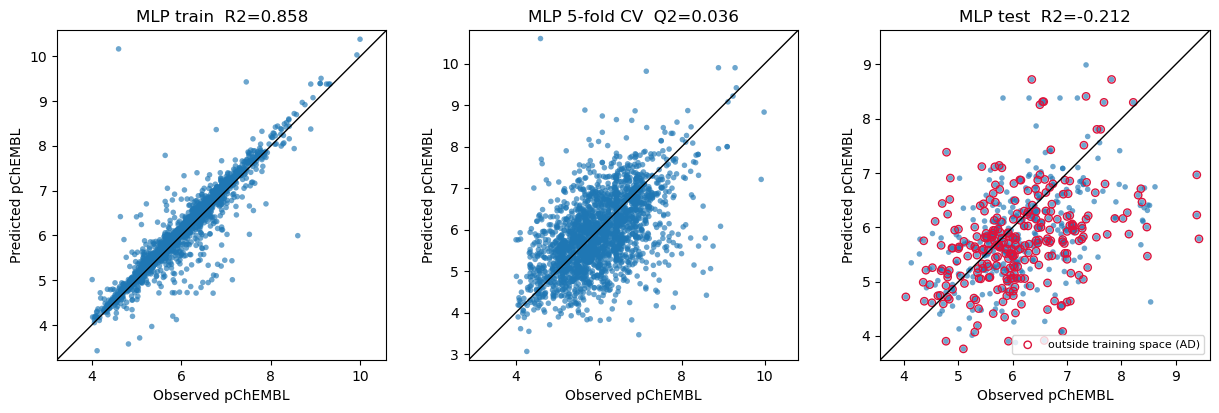

Updated models\ECFP4\test_predictions.csv with pred_MLP


,chembl_id,pchembl_obs,pred_MLP,in_AD,D_Tanimoto,T_c
0,CHEMBL5184762,5.89,5.515327,True,0.320755,0.679245
1,CHEMBL4218901,4.47,5.230093,True,0.300000,0.700000
2,CHEMBL4464527,6.24,6.725873,True,0.269231,0.730769
3,CHEMBL4213975,4.62,5.018061,True,0.270833,0.729167
4,CHEMBL4206647,5.46,5.601490,False,0.392157,0.607843


['models\\ECFP4\\MLPR_ECFP4.pkl']

In [9]:
def make_mlp(n_layers, n_units, activation, alpha, learning_rate_init):
    return Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "mlp",
                MLPRegressor(
                    hidden_layer_sizes=tuple([n_units] * n_layers),
                    activation=activation,
                    alpha=alpha,
                    learning_rate_init=learning_rate_init,
                    solver="adam",
                    max_iter=400,
                    early_stopping=True,
                    validation_fraction=0.1,
                    n_iter_no_change=15,
                    random_state=SEED,
                ),
            ),
        ]
    )


def objective_mlp(trial):
    n_layers = trial.suggest_int("n_layers", 1, 3)
    n_units = trial.suggest_int("n_units", 32, 256, step=32)
    activation = trial.suggest_categorical("activation", ["relu", "tanh"])
    alpha = trial.suggest_float("alpha", 1e-5, 1e-2, log=True)
    lr = trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True)
    return cv_r2_pruned(
        trial, lambda: make_mlp(n_layers, n_units, activation, alpha, lr), X_tr, y_tr, cv_search
    )


studies["MLP"] = run_study("MLP", objective_mlp, N_TRIALS["MLP"])
best_mlp = make_mlp(**studies["MLP"].best_params)
fitted["MLP"], row, preds["MLP"] = evaluate_model("MLP", best_mlp, X_tr, y_tr, X_ts, y_ts, in_ad)
results.append(row)
joblib.dump(fitted["MLP"], MODEL_DIR / "MLPR_ECFP4.pkl")


## 8. k-nearest neighbors

`n_neighbors`, `weights` and distance metric are optimized. Jaccard (Tanimoto distance on binary bits) is included because it is more appropriate for ECFP than Euclidean-only search. The old notebook also overwrote `x_ts` with training fingerprints; predictions now always use `X_ts`.


kNN: best CV R2 = 0.5409
Best params: {'n_neighbors': 5, 'weights': 'distance', 'metric': 'cosine'}
model               kNN
R2_train        0.98941
RMSE_train     0.089427
Q2_CV          0.542742
RMSE_CV        0.587626
MAE_CV         0.411586
R2_ext         0.318978
RMSE_ext       0.773064
MAE_ext        0.576471
CCC_ext        0.551154
R2_ext_AD       0.42612
RMSE_ext_AD    0.697399
AD_coverage    0.481836


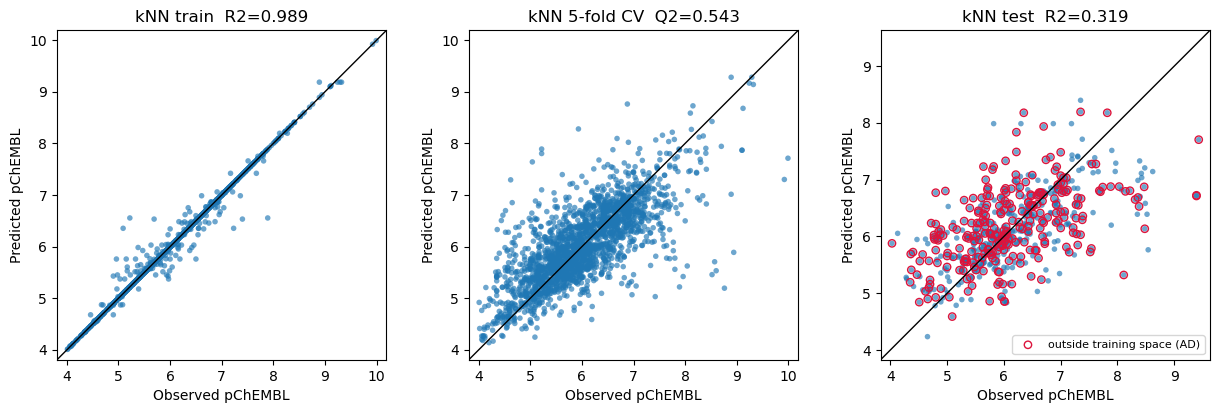

Updated models\ECFP4\test_predictions.csv with pred_kNN


,chembl_id,pchembl_obs,pred_kNN,in_AD,D_Tanimoto,T_c
0,CHEMBL5184762,5.89,6.117021,True,0.320755,0.679245
1,CHEMBL4218901,4.47,5.946898,True,0.300000,0.700000
2,CHEMBL4464527,6.24,6.927593,True,0.269231,0.730769
3,CHEMBL4213975,4.62,5.953521,True,0.270833,0.729167
4,CHEMBL4206647,5.46,6.008316,False,0.392157,0.607843


['models\\ECFP4\\kNN_ECFP4.pkl']

In [10]:
def make_knn(n_neighbors, weights, metric):
    return KNeighborsRegressor(n_neighbors=n_neighbors, weights=weights, metric=metric, n_jobs=-1)


def objective_knn(trial):
    n_neighbors = trial.suggest_int("n_neighbors", 1, 31)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    metric = trial.suggest_categorical("metric", ["euclidean", "jaccard", "cosine"])
    return cv_r2_pruned(trial, lambda: make_knn(n_neighbors, weights, metric), X_tr, y_tr, cv_search)


studies["kNN"] = run_study("kNN", objective_knn, N_TRIALS["kNN"])
best_knn = make_knn(**studies["kNN"].best_params)
fitted["kNN"], row, preds["kNN"] = evaluate_model("kNN", best_knn, X_tr, y_tr, X_ts, y_ts, in_ad)
results.append(row)
joblib.dump(fitted["kNN"], MODEL_DIR / "kNN_ECFP4.pkl")


## 9. Consensus model

Unweighted mean of the four test predictions. No extra fitting on the test set.


model          Consensus
R2_train        0.966735
RMSE_train      0.158494
Q2_CV           0.550612
RMSE_CV         0.582547
MAE_CV          0.420974
R2_ext          0.354207
RMSE_ext        0.752803
MAE_ext         0.568923
CCC_ext         0.537876
R2_ext_AD       0.405401
RMSE_ext_AD     0.709877
AD_coverage     0.481836


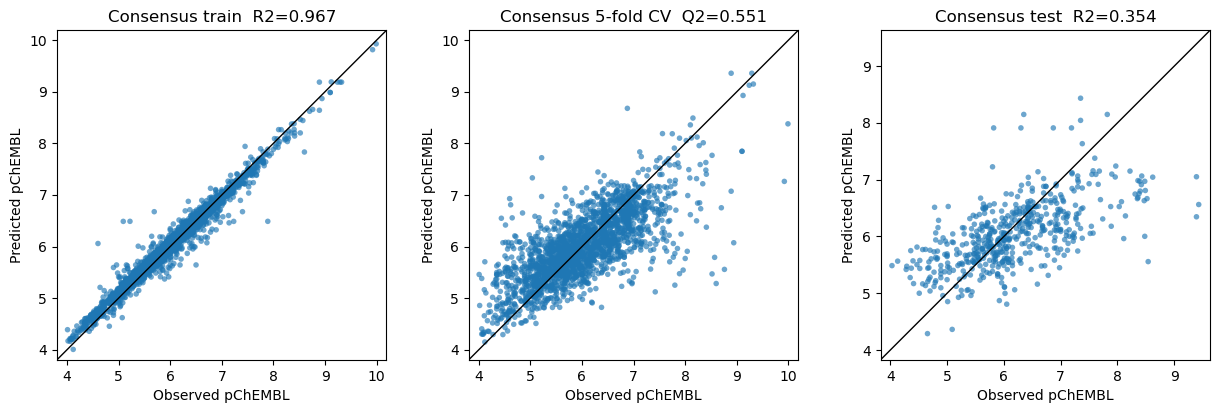

In [11]:
y_hat_cons_tr = np.mean([preds[m]["train"] for m in preds], axis=0)
y_hat_cons_cv = np.mean([preds[m]["cv"] for m in preds], axis=0)
y_hat_cons_ts = np.mean([preds[m]["test"] for m in preds], axis=0)

cons_row = {
    "model": "Consensus",
    "R2_train": r2_score(y_tr, y_hat_cons_tr),
    "RMSE_train": rmse(y_tr, y_hat_cons_tr),
    "Q2_CV": r2_score(y_tr, y_hat_cons_cv),
    "RMSE_CV": rmse(y_tr, y_hat_cons_cv),
    "MAE_CV": mean_absolute_error(y_tr, y_hat_cons_cv),
    "R2_ext": r2_score(y_ts, y_hat_cons_ts),
    "RMSE_ext": rmse(y_ts, y_hat_cons_ts),
    "MAE_ext": mean_absolute_error(y_ts, y_hat_cons_ts),
    "CCC_ext": ccc(y_ts, y_hat_cons_ts),
    "R2_ext_AD": r2_score(y_ts[in_ad], y_hat_cons_ts[in_ad]) if in_ad.any() else np.nan,
    "RMSE_ext_AD": rmse(y_ts[in_ad], y_hat_cons_ts[in_ad]) if in_ad.any() else np.nan,
    "AD_coverage": float(in_ad.mean()),
}
results.append(cons_row)
print(pd.Series(cons_row).to_string())

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.0))
plot_obs_pred(y_tr, y_hat_cons_tr, f"Consensus train  R2={cons_row['R2_train']:.3f}", ax=axes[0])
plot_obs_pred(y_tr, y_hat_cons_cv, f"Consensus 5-fold CV  Q2={cons_row['Q2_CV']:.3f}", ax=axes[1])
plot_obs_pred(y_ts, y_hat_cons_ts, f"Consensus test  R2={cons_row['R2_ext']:.3f}", ax=axes[2])
plt.tight_layout()
plt.show()

pred_table["pred_Consensus"] = y_hat_cons_ts
pred_table.to_csv(MODEL_DIR / "test_predictions.csv", index=False)


## 10. Model comparison

External R² is the primary ranking metric because the test set is a scaffold hold-out. A simple Tropsha-style check is reported (`Q² > 0.5`, `R²_ext > 0.6`, `|R²_ext − Q²| < 0.3`).


,R2_train,RMSE_train,Q2_CV,RMSE_CV,MAE_CV,R2_ext,RMSE_ext,MAE_ext,CCC_ext,R2_ext_AD,RMSE_ext_AD,AD_coverage,valid_tropsha
model,,,,,,,,,,,,,
CatBoost,0.927,0.234,0.567,0.572,0.411,0.395,0.728,0.553,0.546,0.480,0.664,0.482,False
SVR,0.944,0.205,0.506,0.611,0.452,0.353,0.753,0.580,0.519,0.462,0.675,0.482,False
MLP,0.858,0.327,0.036,0.853,0.632,-0.212,1.031,0.788,0.381,-0.143,0.984,0.482,False
kNN,0.989,0.089,0.543,0.588,0.412,0.319,0.773,0.576,0.551,0.426,0.697,0.482,False
Consensus,0.967,0.158,0.551,0.583,0.421,0.354,0.753,0.569,0.538,0.405,0.710,0.482,False


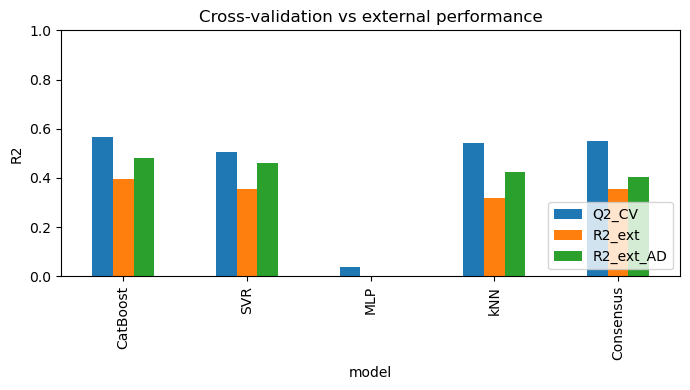

Best single model by external R2: CatBoost


['models\\ECFP4\\optuna_studies.pkl']

In [12]:
summary = pd.DataFrame(results).set_index("model")
summary["valid_tropsha"] = (
    (summary["Q2_CV"] > 0.5)
    & (summary["R2_ext"] > 0.6)
    & ((summary["R2_ext"] - summary["Q2_CV"]).abs() < 0.3)
)
display(summary.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
summary[["Q2_CV", "R2_ext", "R2_ext_AD"]].plot(kind="bar", ax=ax)
ax.set_ylabel("R2")
ax.set_ylim(0, 1)
ax.set_title("Cross-validation vs external performance")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

best_name = summary.drop(index=["Consensus"], errors="ignore")["R2_ext"].idxmax()
print("Best single model by external R2:", best_name)

summary.round(4).to_csv(MODEL_DIR / "metrics_summary.csv")
joblib.dump({k: v.best_params for k, v in studies.items()}, MODEL_DIR / "best_params.pkl")
joblib.dump(studies, MODEL_DIR / "optuna_studies.pkl")


## 11. Y-randomization

`permutation_test_score` shuffles the training endpoint and repeats CV. A real structure–activity relationship should give a high true Q² and a near-zero (or negative) mean randomized score with a small p-value.


In [ ]:
y_rand_rows = []
for name, est in fitted.items():
    perm_kwargs = {}
    if name == "CatBoost":
        perm_kwargs["params"] = {"verbose": False}
    score, perm_scores, pvalue = permutation_test_score(
        clone(est),
        X_tr,
        y_tr,
        cv=cv_final,
        scoring="r2",
        n_permutations=N_PERMUTATIONS,
        n_jobs=1 if name == "CatBoost" else -1,
        random_state=SEED,
        **perm_kwargs,
    )
    y_rand_rows.append(
        {
            "model": name,
            "true_Q2": score,
            "y_rand_mean": float(np.mean(perm_scores)),
            "y_rand_std": float(np.std(perm_scores)),
            "p_value": float(pvalue),
        }
    )
    print(
        f"{name}: true Q2 = {score:.3f}, "
        f"Y-randomization = {np.mean(perm_scores):.3f} ± {np.std(perm_scores):.3f}, "
        f"p = {pvalue:.4f}"
    )

y_rand = pd.DataFrame(y_rand_rows).set_index("model")
display(y_rand.round(4))
y_rand.round(4).to_csv(MODEL_DIR / "y_randomization.csv")
